In [64]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import sys


sys.path.append('..')

from sklearn import set_config
set_config(transform_output="pandas")
from scipy.stats import randint, uniform
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from src.utils import DEV_SET_CLEAN_NORMAL_PATH, COLS, DEV_SET_CLEAN_OUTLIERS_PATH, DEV_SET_CLEAN_PATH
from src.config import TREE_BASED_CONFIG_NORMAL, TREE_BASED_CONFIG_OUTLIERS
from src.pipeline import build_feature_pipeline, build_target_pipeline
from src.plots import plot_cv_results, plot_grid_search_results
from src.model_evaluation import evaluate_models_cv, grid_search_cv

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


En este notebook vamos a hacer una busqueda de hiperparámetros y comparar la performance de modelos de XGBoost, LightGBM y Random Forest

# 1. Dataset Normal

In [65]:
OVERFITTING_CUTOFF = 70

df_normal = pd.read_csv("../" + DEV_SET_CLEAN_NORMAL_PATH)
X_normal = df_normal.drop(columns=[COLS.TARGET])
y_normal = df_normal[COLS.TARGET]

In [66]:
# construimos pipelines
feature_pipeline_normal = build_feature_pipeline(TREE_BASED_CONFIG_NORMAL)
target_pipeline_normal = build_target_pipeline(TREE_BASED_CONFIG_NORMAL)

## 1.1 Modelos base
Entrenamos modelos baseline con hiperparámetros predeterminados para tener un baseline para comparar


In [67]:
base_models = {
    'XBoost': XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    # 'RandomForest': RandomForestRegressor(
    #     random_state=42,
    #     max_depth=10, # solo limitamos max_depth para que no tarde una eternidad
    #     n_jobs=-1
    # )
}

In [68]:
base_normal_results = evaluate_models_cv(
    base_models,
    X_normal,
    y_normal,
    feature_pipeline_normal,
    target_pipeline_normal
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando XBoost...
  ✓ MAE: 4,991 ± 46
  ✓ RMSE: 11,595 ± 369

Entrenando LightGBM...
  ✓ MAE: 5,887 ± 77
  ✓ RMSE: 14,084 ± 355



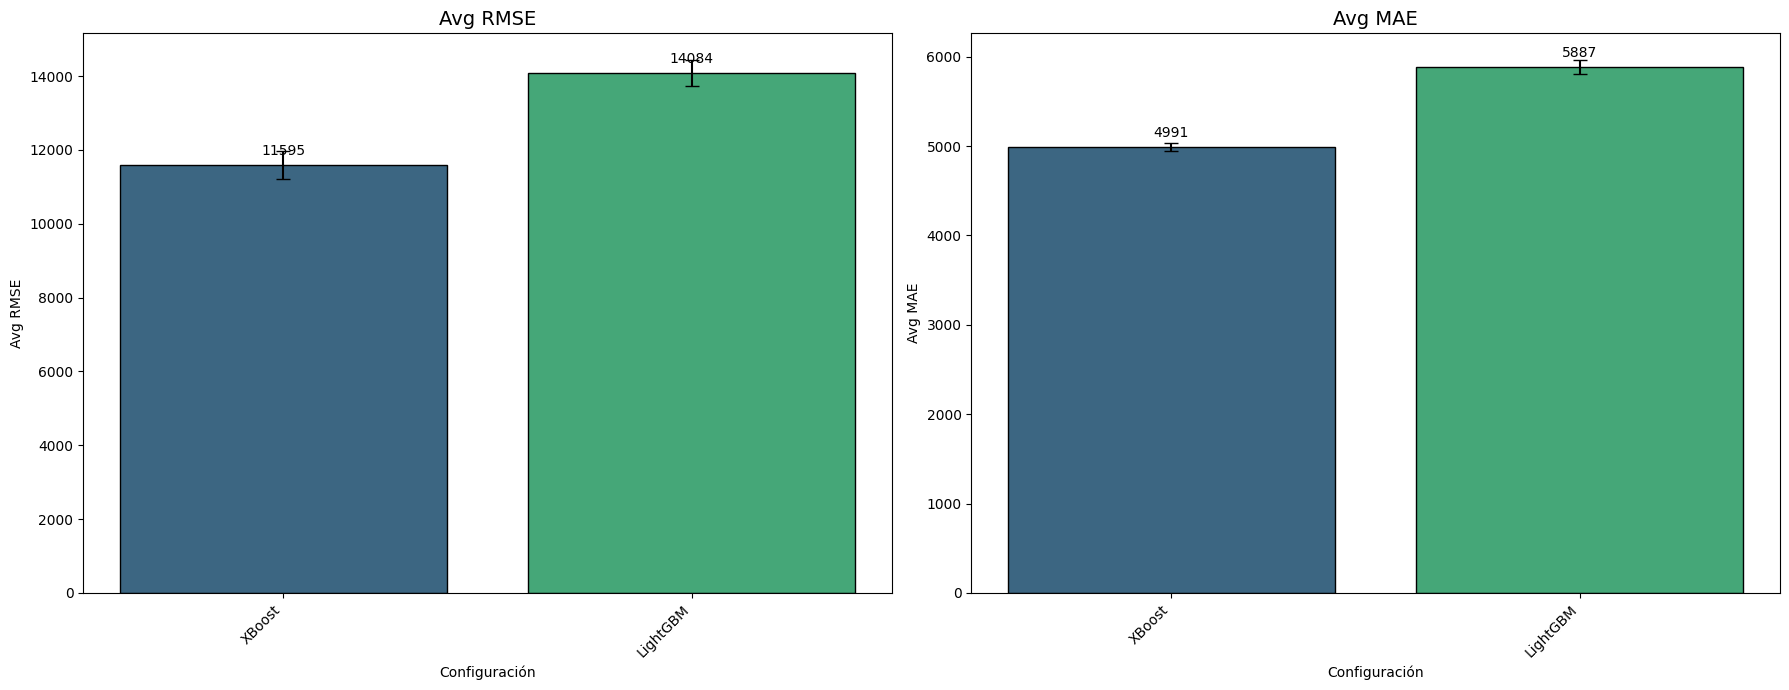

In [69]:
plot_cv_results(base_normal_results, vertical_layout=False)

## 1.2 Grid Search - XGBoost

In [70]:
xgb_random_search_params = {
    'max_depth': randint(6, 15),
    'learning_rate': uniform(0.01, 0.3),
    'n_estimators': [300, 500, 600, 800, 900, 1000],
    'min_child_weight': randint(1, 20),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0.0, 0.5),
    'reg_lambda': uniform(0.0, 5.0)
}

In [71]:
xgb_grid_results = grid_search_cv(
    model_class=XGBRegressor,
    param_grid=xgb_random_search_params,
    X=X_normal,
    y=y_normal,
    feature_pipeline=feature_pipeline_normal,
    target_pipeline=target_pipeline_normal,
    n_splits=3,
    n_iter=500,
    verbose=True
)


🔍 RandomizedSearchCV: 500 combinaciones × 3 folds = 1500 fits
   Modelo: XGBRegressor



Optimizando:   0%|          | 0/1500 [00:00<?, ?it/s]


KeyboardInterrupt



In [48]:
xgb_grid_results.to_csv("../results/random_search/xgb_normal.csv")

def get_best_not_overfitted(results):
    results_out = results.copy()
    return results_out[results_out['overfit_gap_%'] < OVERFITTING_CUTOFF].sort_values('rmse_mean')

xgb_grid_results_cut = get_best_not_overfitted(xgb_grid_results)
xgb_grid_results_cut.head()

,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
13,0.612572,0.318205,0.104307,9,5,900,2.699205,0.681224,3119.483564,15.072981,7921.187902,181.325196,1939.058081,37.727478,3853.845615,105.896282,60.876231
12,0.939566,0.360865,0.080795,12,9,500,0.127096,0.643157,3082.694956,7.448634,8035.777779,148.432525,1830.874256,30.440825,3823.862371,102.127482,68.372839
3,0.716858,0.183181,0.146821,8,12,800,2.962073,0.618580,3563.934126,14.405113,8585.958615,216.748047,2584.451365,38.250712,5355.585596,110.340154,37.899060
6,0.865009,0.155856,0.166020,9,18,500,2.248771,0.758060,3520.192311,16.329452,8603.539052,146.576123,2506.401948,28.576633,5266.462642,95.928471,40.448036
14,0.977141,0.299433,0.218435,7,10,900,1.478168,0.642198,3615.992584,27.906262,8649.737576,124.340148,2525.573987,58.405899,4989.716696,145.182355,43.175080


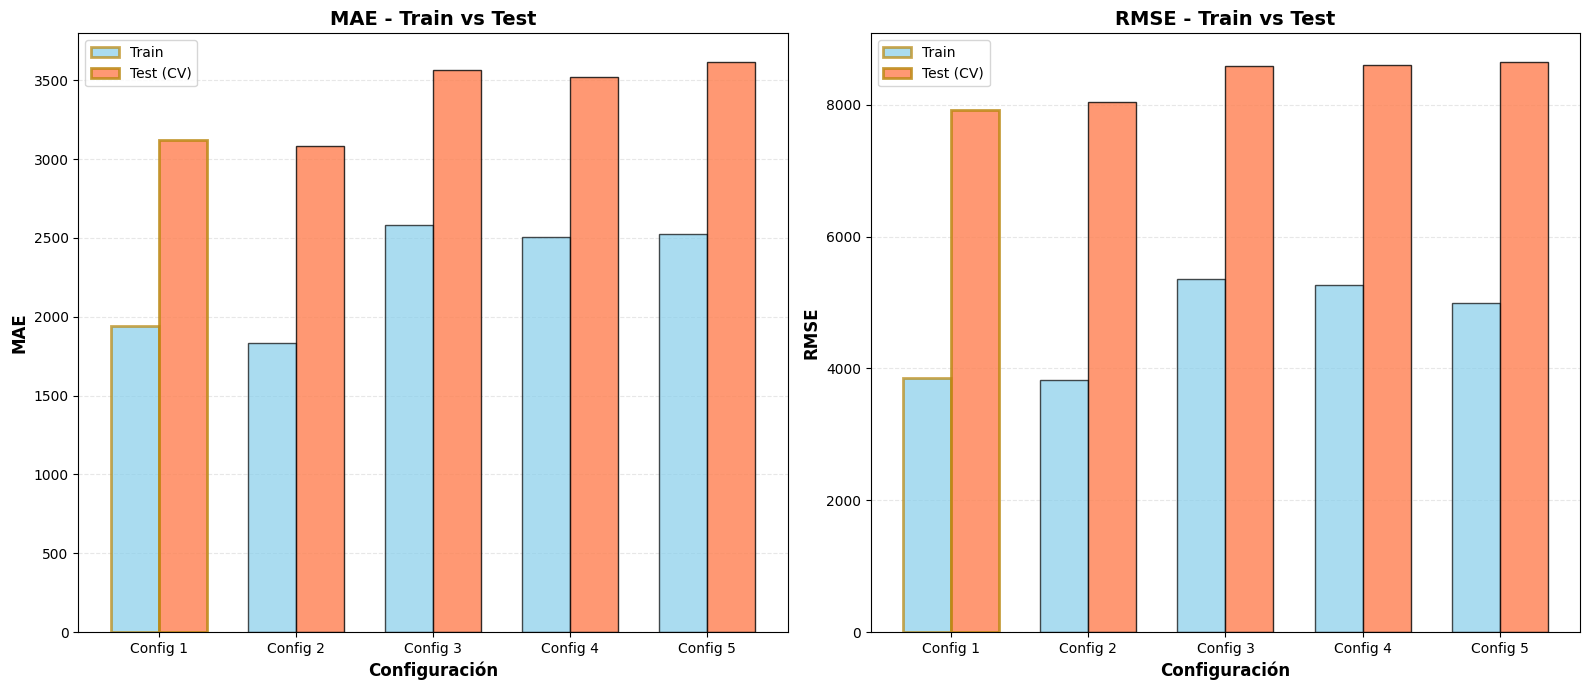


📋 Parámetros de cada configuración:
          colsample_bytree     gamma  learning_rate  max_depth  min_child_weight  n_estimators  reg_lambda  subsample     mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.612572  0.318205       0.104307          9                 5           900    2.699205   0.681224  3119.483564     1939.058081      60.876231
Config 2          0.939566  0.360865       0.080795         12                 9           500    0.127096   0.643157  3082.694956     1830.874256      68.372839
Config 3          0.716858  0.183181       0.146821          8                12           800    2.962073   0.618580  3563.934126     2584.451365      37.899060
Config 4          0.865009  0.155856       0.166020          9                18           500    2.248771   0.758060  3520.192311     2506.401948      40.448036
Config 5          0.977141  0.299433       0.218435          7                10           900    1.478168   0.642198  3615.992584     2525.573987      4

In [36]:
plot_grid_search_results(xgb_grid_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

## 1.3 Grid Search - LightGBM

In [11]:
lgbm_param_grid = {
    # Complejidad del árbol (equivalente a max_depth)
    'num_leaves': randint(10, 50),        # [10, 49] - Conservador para evitar overfitting

    # Learning rate y número de árboles
    'learning_rate': uniform(0.01, 0.29),
    'n_estimators': [300, 500, 800, 1000, 1200],

    # Regularización (prevenir overfitting)
    'min_child_samples': randint(10, 50), # [10, 49] - Mínimo de muestras por hoja
    'min_child_weight': uniform(0, 20), # [0.001, 0.1] - Peso mínimo

    # Subsampling (añade randomness)
    'subsample': uniform(0.6, 0.4),       # [0.6, 1.0]
    'colsample_bytree': uniform(0.6, 0.4),# [0.6, 1.0]

    # Regularización L1/L2
    'reg_alpha': uniform(0, 5.0),         # [0, 2.0] - L1
    'reg_lambda': uniform(0, 5.0),        # [0, 2.0] - L2
}

In [12]:
lgbm_grid_results = grid_search_cv(
    model_class=LGBMRegressor,
    param_grid=lgbm_param_grid,
    X=X_normal,
    y=y_normal,
    feature_pipeline=feature_pipeline_normal,
    target_pipeline=target_pipeline_normal,
    n_splits=3,
    verbose=True,
    n_iter=500,
)


🔍 RandomizedSearchCV: 10 combinaciones × 5 folds = 50 fits
   Modelo: LGBMRegressor



Optimizando:   0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.147422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2362
[LightGBM] [Info] Number of data points in the train set: 213331, number of used features: 39
[LightGBM] [Info] Start training from score 24027.854187
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2366
[LightGBM] [Info] Number of data points in the train set: 213331, number of used features: 39
[LightGBM] [Info] Start training from score 24093.392110
[LightGBM] [Warnin

/Users/gonza/Documents/Gonza/UdeSA/05-machine-learning/alquileres/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053529 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2366
[LightGBM] [Info] Number of data points in the train set: 213332, number of used features: 39
[LightGBM] [Info] Start training from score 24025.020396
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.192797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2362
[LightGBM] [Info] Number of data points in the train set: 213331, number of used features: 39
[LightGBM] [Info] Start training from score 24027.854187
[LightGBM] [Warnin

In [49]:
lgbm_grid_results.to_csv("../results/random_search/lgbm_normal.csv")

lgbm_grid_results_cut = get_best_not_overfitted(lgbm_grid_results)
lgbm_grid_results_cut.head()

,colsample_bytree,learning_rate,min_child_samples,min_child_weight,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
9,0.965984,0.256511,21,6.617960,1200,44,2.956489,1.373609,0.824497,3229.051531,30.268959,7863.692758,256.117260,2255.334604,7.198467,4571.043707,52.614213,43.173945
8,0.602209,0.246484,26,14.226839,800,42,3.029800,4.631504,0.860431,3657.942277,25.936488,8667.484116,218.355019,2920.649462,14.265622,6169.386671,63.686178,25.244139
4,0.648815,0.153601,44,18.186408,1000,49,3.776807,2.125779,0.683177,3629.457834,18.192707,8738.475280,218.605583,2935.872360,13.849595,6453.559538,66.392210,23.624511
0,0.749816,0.285707,17,11.973170,500,28,0.499875,2.296244,0.733483,4095.513858,33.081092,9549.141559,268.180224,3510.213501,17.487564,7480.883618,67.769372,16.674210
1,0.657147,0.198758,11,14.439975,500,30,3.087408,3.058266,0.602827,4214.411564,33.251663,9904.769479,274.893842,3726.518991,19.815444,8125.444610,57.116361,13.092448


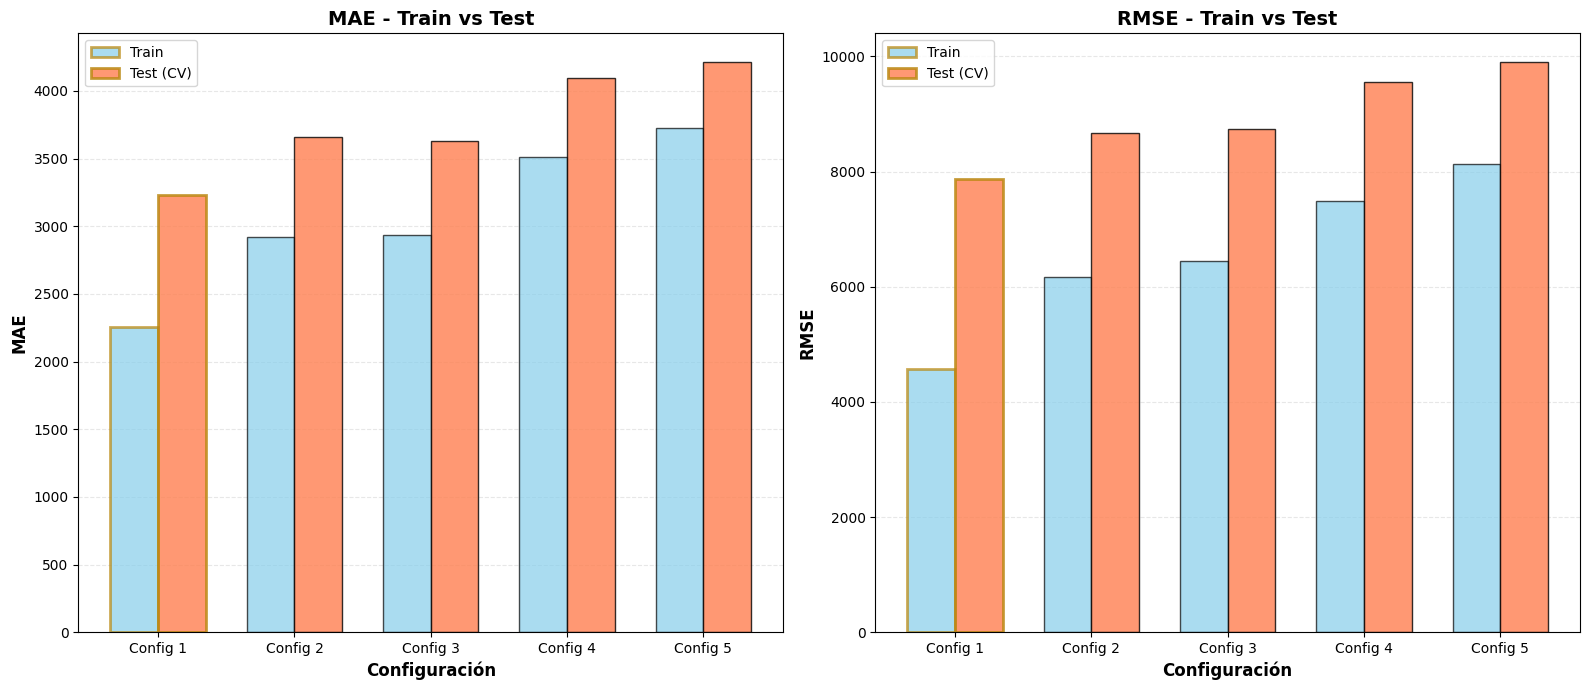


📋 Parámetros de cada configuración:
          colsample_bytree  learning_rate  min_child_samples  min_child_weight  n_estimators  num_leaves  reg_alpha  reg_lambda  subsample     mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.965984       0.256511                 21          6.617960          1200          44   2.956489    1.373609   0.824497  3229.051531     2255.334604      43.173945
Config 2          0.602209       0.246484                 26         14.226839           800          42   3.029800    4.631504   0.860431  3657.942277     2920.649462      25.244139
Config 3          0.648815       0.153601                 44         18.186408          1000          49   3.776807    2.125779   0.683177  3629.457834     2935.872360      23.624511
Config 4          0.749816       0.285707                 17         11.973170           500          28   0.499875    2.296244   0.733483  4095.513858     3510.213501      16.674210
Config 5          0.657147       0.198758       

In [39]:
plot_grid_search_results(lgbm_grid_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

# 2. Dataset Outliers

In [15]:
df_outliers = pd.read_csv("../" + DEV_SET_CLEAN_OUTLIERS_PATH)
X_outliers = df_outliers.drop(columns=[COLS.TARGET])
y_outliers = df_outliers[COLS.TARGET]

In [16]:
# construimos pipelines
feature_pipeline_outliers = build_feature_pipeline(TREE_BASED_CONFIG_OUTLIERS)
target_pipeline_outliers = build_target_pipeline(TREE_BASED_CONFIG_OUTLIERS)

## 2.1 Modelos base

In [17]:
base_outliers_results = evaluate_models_cv(
    base_models,
    X_outliers,
    y_outliers,
    feature_pipeline_outliers,
    target_pipeline_outliers
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando XBoost...
  ✓ MAE: 458,953 ± 24,058
  ✓ RMSE: 1,140,202 ± 162,189

Entrenando LightGBM...
  ✓ MAE: 583,349 ± 38,693
  ✓ RMSE: 1,286,722 ± 193,552

Entrenando RandomForest...
  ✓ MAE: 703,622 ± 39,175
  ✓ RMSE: 1,346,570 ± 221,150



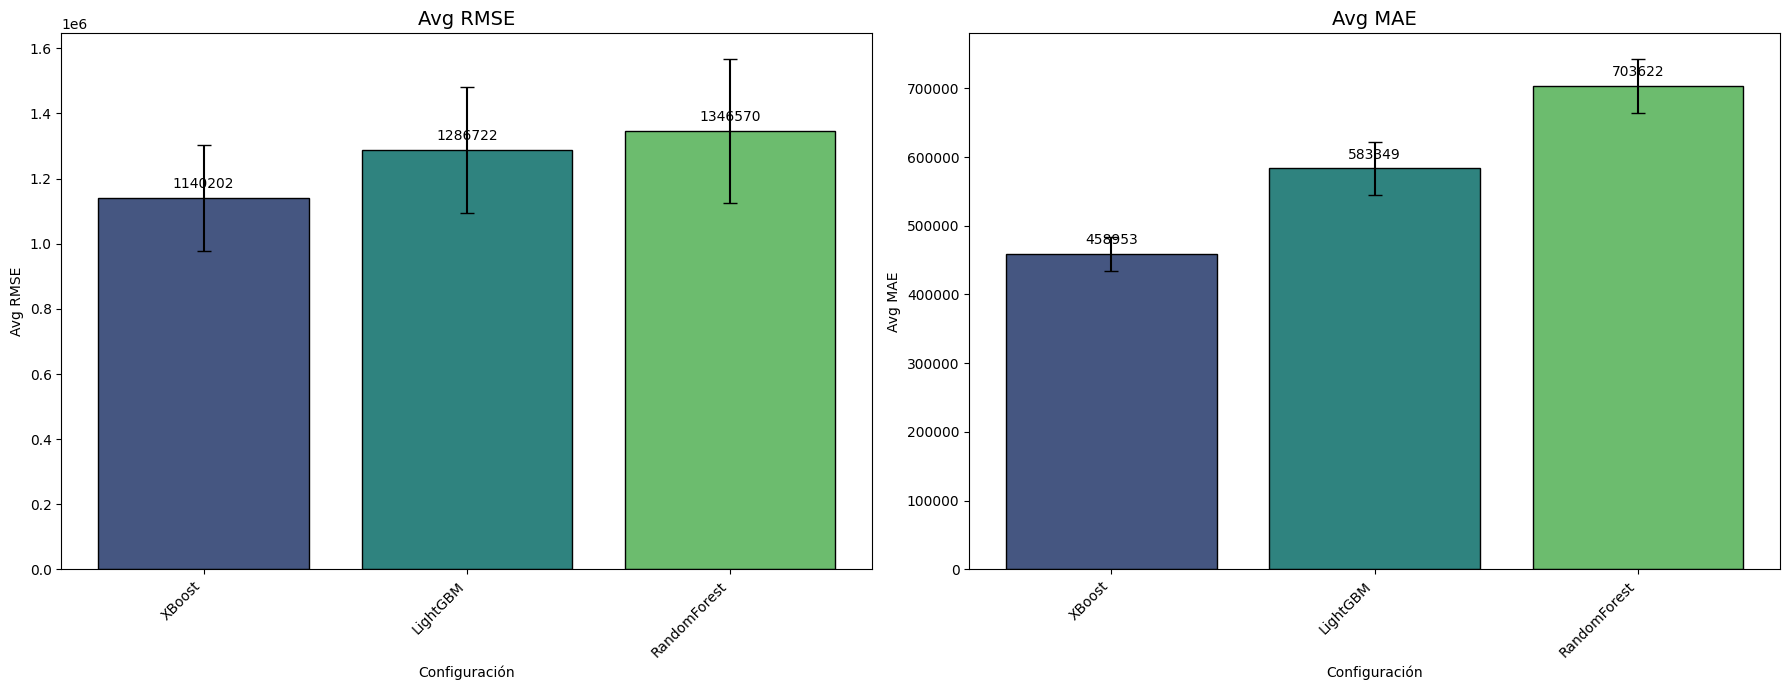

In [18]:
plot_cv_results(base_outliers_results, vertical_layout=False)

## 2.2 Grid Search - XGBoost
En este dataset las muestras son muy pocas -- vamos a ser más cuidadosos con el overfitting

In [19]:
xgb_random_search_params_outliers = {
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.005, 0.045),
    'n_estimators': [500, 700, 1000, 1500], # Más árboles simples

    # Regularización fuerte
    'min_child_weight': randint(5, 30),
    'min_child_samples': randint(3, 15),
    'gamma': uniform(0.1, 0.9),           # [0.1, 1.0] vs [0.0, 0.5]
    'reg_alpha': uniform(0.5, 2.5),       # [0.5, 3.0] - L1 regularization
    'reg_lambda': uniform(1.0, 4.0),      # [1.0, 5.0] vs [0.0, 5.0] - L2 ALTO

    # Subsampling MÁS AGRESIVO (más randomness)
    'subsample': uniform(0.5, 0.4),       # [0.5, 0.9] vs [0.6, 1.0]
    'colsample_bytree': uniform(0.5, 0.4),# [0.5, 0.9] vs [0.6, 1.0]
    'subsample_freq': [1],                # Hacer subsample en cada iteración

}

In [20]:
xgb_outliers_results = grid_search_cv(
    model_class=XGBRegressor,
    param_grid=xgb_random_search_params,
    X=X_outliers,
    y=y_outliers,
    feature_pipeline=feature_pipeline_outliers,
    target_pipeline=target_pipeline_outliers,
    n_splits=5,
    n_iter=1000,
    verbose=True
)


🔍 RandomizedSearchCV: 15 combinaciones × 3 folds = 45 fits
   Modelo: XGBRegressor



Optimizando:   0%|          | 0/45 [00:00<?, ?it/s]


✅ Mejor MAE: 582,894
   Mejores params: {'regressor__model__colsample_bytree': np.float64(0.8430179407605753), 'regressor__model__gamma': np.float64(0.08526206184364576), 'regressor__model__learning_rate': np.float64(0.029515477895583855), 'regressor__model__max_depth': 9, 'regressor__model__min_child_weight': 14, 'regressor__model__n_estimators': 500, 'regressor__model__reg_lambda': np.float64(1.9270825126995805), 'regressor__model__subsample': np.float64(0.6063865008880857)}
   Overfitting gap: 65.2% ❌ (overfitting!)


In [50]:
xgb_outliers_results.to_csv("../results/random_search/xgb_outliers.csv")
xgb_outliers_results_cut = get_best_not_overfitted(xgb_outliers_results)
xgb_outliers_results_cut.head()

,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
4,0.843018,0.085262,0.029515,9,14,500,1.927083,0.606387,582893.548272,12490.906319,1.281454e+06,123399.173783,352754.385324,10312.065661,774505.295439,33219.709149,65.240624
5,0.692358,0.120513,0.214979,13,15,600,4.546602,0.703512,613497.308318,17619.929251,1.294552e+06,112786.868891,378856.246909,15874.765281,817498.504649,39156.428435,61.934062
11,0.724393,0.162592,0.228882,13,3,300,1.914634,0.988685,633016.698306,10949.255443,1.353160e+06,106471.761126,380117.851224,2018.306100,824724.420333,22625.843247,66.531694
3,0.716858,0.183181,0.146821,8,12,800,2.962073,0.618580,646307.160415,22447.325178,1.357696e+06,139063.886423,428715.213454,11368.323425,884061.118693,26185.887117,50.754426
6,0.865009,0.155856,0.166020,9,18,500,2.248771,0.758060,652668.653215,2462.342989,1.375394e+06,84576.858823,427531.570829,14163.421992,899573.654235,53859.734923,52.659756


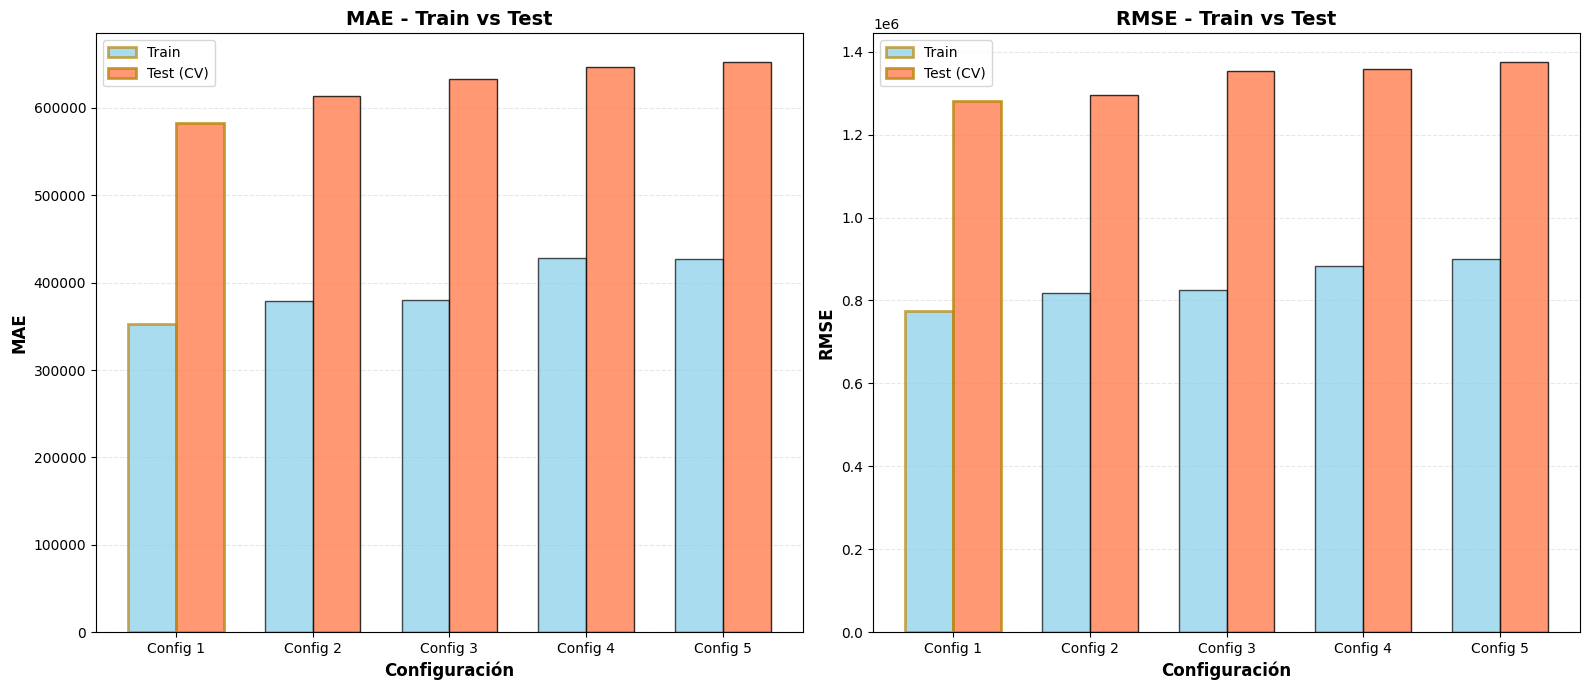


📋 Parámetros de cada configuración:
          colsample_bytree     gamma  learning_rate  max_depth  min_child_weight  n_estimators  reg_lambda  subsample       mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.843018  0.085262       0.029515          9                14           500    1.927083   0.606387  582893.548272   352754.385324      65.240624
Config 2          0.692358  0.120513       0.214979         13                15           600    4.546602   0.703512  613497.308318   378856.246909      61.934062
Config 3          0.724393  0.162592       0.228882         13                 3           300    1.914634   0.988685  633016.698306   380117.851224      66.531694
Config 4          0.716858  0.183181       0.146821          8                12           800    2.962073   0.618580  646307.160415   428715.213454      50.754426
Config 5          0.865009  0.155856       0.166020          9                18           500    2.248771   0.758060  652668.653215   427531.5

In [41]:
plot_grid_search_results(xgb_outliers_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

## 2.3 Grid Search - LightGBM

In [21]:
lgbm_params_outliers = {
    # Árboles MUY SIMPLES
    'num_leaves': randint(5, 20),         # [5, 19] vs [20, 79]

    # Learning rate BAJÍSIMO + más árboles
    'learning_rate': uniform(0.003, 0.047), # [0.003, 0.05] vs [0.01, 0.30]
    'n_estimators': [500, 700, 1000, 1500, 2000],

    # Regularización FUERTE (muchos samples por nodo)
    'min_child_samples': randint(5, 20),  # [5, 19] - Alto para dataset chico
    'min_data_in_leaf': randint(5, 20),   # [5, 19]
    'min_child_weight': uniform(0.01, 0.49), # [0.01, 0.5] vs [0.001, 0.1]

    # Subsampling AGRESIVO
    'subsample': uniform(0.5, 0.4),       # [0.5, 0.9] vs [0.6, 1.0]
    'colsample_bytree': uniform(0.5, 0.4),# [0.5, 0.9] vs [0.6, 1.0]
    'subsample_freq': [1],                # Siempre hacer bagging

    # Penalizaciones FUERTES
    'reg_alpha': uniform(0.5, 3.5),       # [0.5, 4.0] vs [0.0, 2.0] - L1
    'reg_lambda': uniform(1.0, 4.0),      # [1.0, 5.0] vs [0.0, 3.0] - L2

    # PATH_SMOOTH (específico de LightGBM - previene overfitting)
    'path_smooth': uniform(0.5, 1.5),     # [0.5, 2.0] - Suaviza predicciones
}


In [22]:
lgbm_outliers_results = grid_search_cv(
    model_class=LGBMRegressor,
    param_grid=lgbm_params_outliers,
    X=X_outliers,
    y=y_outliers,
    feature_pipeline=feature_pipeline_outliers,
    target_pipeline=target_pipeline_outliers,
    n_splits=5,
    verbose=True,
    n_iter=1000,
)


🔍 RandomizedSearchCV: 10 combinaciones × 5 folds = 50 fits
   Modelo: LGBMRegressor



Optimizando:   0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Warning] min_data_in_leaf is set=9, min_child_samples=15 will be ignored. Current value: min_data_in_leaf=9
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=9, min_child_samples=15 will be ignored. Current value: min_data_in_leaf=9
[LightGBM] [Warning] min_data_in_leaf is set=9, min_child_samples=15 will be ignored. Current value: min_data_in_leaf=9
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=9, min_child_samples=15 will be ignored. Current value: min_data_in_leaf=9
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1588
[LightGBM] [Info] Number of data points in the train set: 3246, number of used features: 38
[LightGB

In [51]:
lgbm_outliers_results.to_csv("../results/random_search/lgbm_outliers.csv")
lgbm_outliers_results_cut = get_best_not_overfitted(lgbm_outliers_results)
lgbm_outliers_results_cut.head()

,colsample_bytree,learning_rate,min_child_samples,min_child_weight,min_data_in_leaf,n_estimators,num_leaves,path_smooth,reg_alpha,reg_lambda,...,subsample_freq,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
2,0.616492,0.031757,14,0.032866,16,1000,16,1.271352,2.573451,1.185802,...,1,611658.759829,44226.468022,1.311518e+06,236809.430827,433770.663375,7405.431671,9.309788e+05,32439.326050,41.009711
6,0.884469,0.042693,17,0.142961,9,700,13,0.921402,2.399436,1.563697,...,1,612237.773290,46511.406845,1.317706e+06,239243.582758,441371.585381,7588.044394,9.426639e+05,32568.896606,38.712548
4,0.548815,0.026273,19,0.094949,5,1500,6,1.493783,1.590989,3.080272,...,1,731599.544670,45019.004932,1.468526e+06,228275.066902,604668.584721,9166.440492,1.188697e+06,39804.586472,20.991823
7,0.529820,0.049384,12,0.203492,12,1000,7,1.560286,3.051525,4.085081,...,1,729201.649551,39928.459703,1.472431e+06,221693.388212,592567.455405,13022.206843,1.188192e+06,53826.165108,23.057998
0,0.649816,0.047684,15,0.392049,9,700,7,0.649962,2.107371,2.334834,...,1,743407.667622,44584.272107,1.498362e+06,234178.777524,610097.558771,7850.582824,1.214869e+06,36058.679518,21.850622


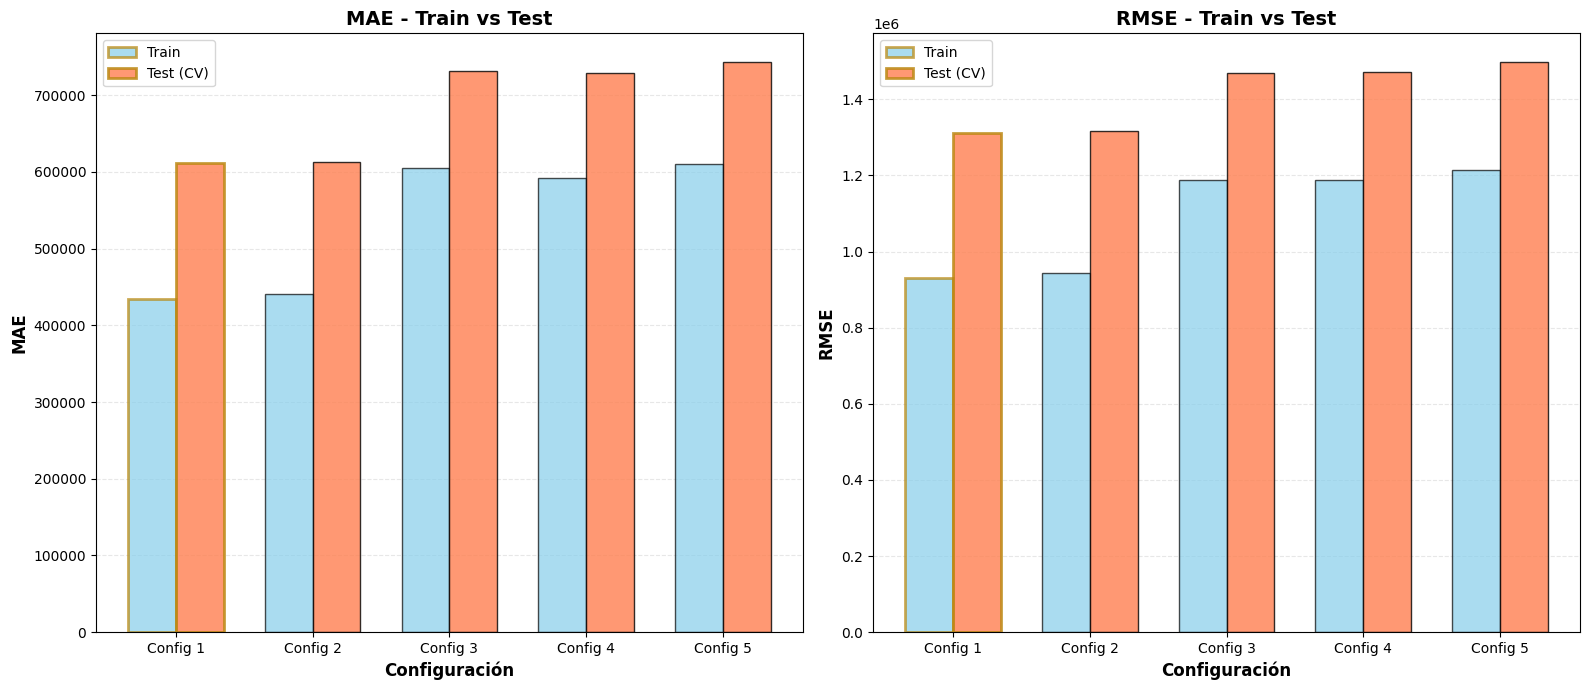


📋 Parámetros de cada configuración:
          colsample_bytree  learning_rate  min_child_samples  min_child_weight  min_data_in_leaf  n_estimators  num_leaves  path_smooth  reg_alpha  reg_lambda  subsample  subsample_freq       mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.616492       0.031757                 14          0.032866                16          1000          16     1.271352   2.573451    1.185802   0.743018               1  611658.759829   433770.663375      41.009711
Config 2          0.884469       0.042693                 17          0.142961                 9           700          13     0.921402   2.399436    1.563697   0.820879               1  612237.773290   441371.585381      38.712548
Config 3          0.548815       0.026273                 19          0.094949                 5          1500           6     1.493783   1.590989    3.080272   0.718684               1  731599.544670   604668.584721      20.991823
Config 4          0.529820       0.

In [43]:
plot_grid_search_results(lgbm_outliers_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

# 3. Dataset completo

In [23]:
df_full = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
X_full = df_full.drop(columns=[COLS.TARGET])
y_full = df_full[COLS.TARGET]

3.1 Modelos Base

In [24]:
base_full_results = evaluate_models_cv(
    base_models,
    X_full,
    y_full,
    feature_pipeline_normal,
    target_pipeline_normal
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando XBoost...
  ✓ MAE: 98,612 ± 1,119
  ✓ RMSE: 481,954 ± 39,288

Entrenando LightGBM...
  ✓ MAE: 100,700 ± 935
  ✓ RMSE: 534,640 ± 30,521

Entrenando RandomForest...
  ✓ MAE: 97,920 ± 1,341
  ✓ RMSE: 529,887 ± 36,681



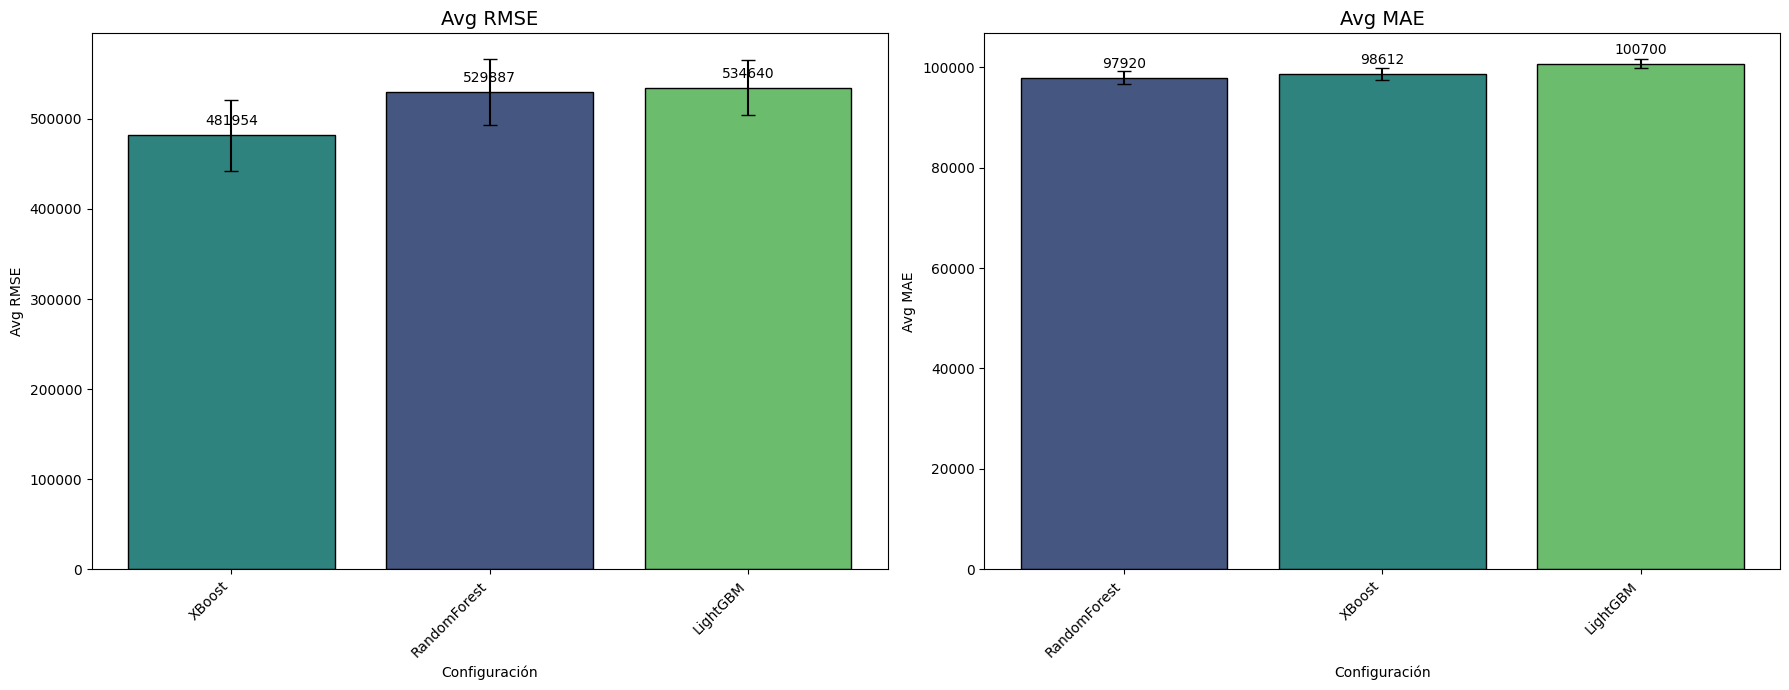

In [25]:
plot_cv_results(base_full_results, vertical_layout=False)

## 3.2 Grid Search - XGBoost

In [26]:
xgb_full_results = grid_search_cv(
    model_class=XGBRegressor,
    param_grid=xgb_random_search_params,
    X=X_full,
    y=y_full,
    feature_pipeline=feature_pipeline_normal,
    target_pipeline=target_pipeline_normal,
    n_splits=3,
    n_iter=300,
    verbose=True
)


🔍 RandomizedSearchCV: 15 combinaciones × 3 folds = 45 fits
   Modelo: XGBRegressor



Optimizando:   0%|          | 0/45 [00:00<?, ?it/s]


✅ Mejor MAE: 84,346
   Mejores params: {'regressor__model__colsample_bytree': np.float64(0.7243929286862649), 'regressor__model__gamma': np.float64(0.16259166101337352), 'regressor__model__learning_rate': np.float64(0.22888185350141924), 'regressor__model__max_depth': 13, 'regressor__model__min_child_weight': 3, 'regressor__model__n_estimators': 300, 'regressor__model__reg_lambda': np.float64(1.914634373768949), 'regressor__model__subsample': np.float64(0.9886848381556415)}
   Overfitting gap: 250.6% ❌ (overfitting!)


In [52]:
xgb_full_results.to_csv("../results/random_search/xgb_full.csv")
xgb_full_results_cut = get_best_not_overfitted(xgb_full_results)
xgb_full_results_cut.head()

,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
13,0.612572,0.318205,0.104307,9,5,900,2.699205,0.681224,99871.440149,327.366578,423203.570393,21387.827179,68969.971887,1511.742271,234148.091532,8934.814247,44.804235
12,0.939566,0.360865,0.080795,12,9,500,0.127096,0.643157,100775.293035,377.482091,424942.685944,19343.549574,69122.108306,1252.675499,244093.299189,8077.124867,45.793141
0,0.749816,0.475357,0.229598,10,7,500,0.779973,0.623233,127667.470047,1443.206402,437657.772418,17188.489525,80140.226910,2127.246182,211592.190811,9454.957539,59.305102
3,0.716858,0.183181,0.146821,8,12,800,2.962073,0.618580,120806.083224,488.223590,444668.136981,18457.120018,95872.751280,1285.129169,308219.273341,10060.195305,26.006693
6,0.865009,0.155856,0.166020,9,18,500,2.248771,0.758060,119067.907157,569.124613,445426.706049,19403.186125,93823.826489,1243.098294,312284.641583,9506.581086,26.905832


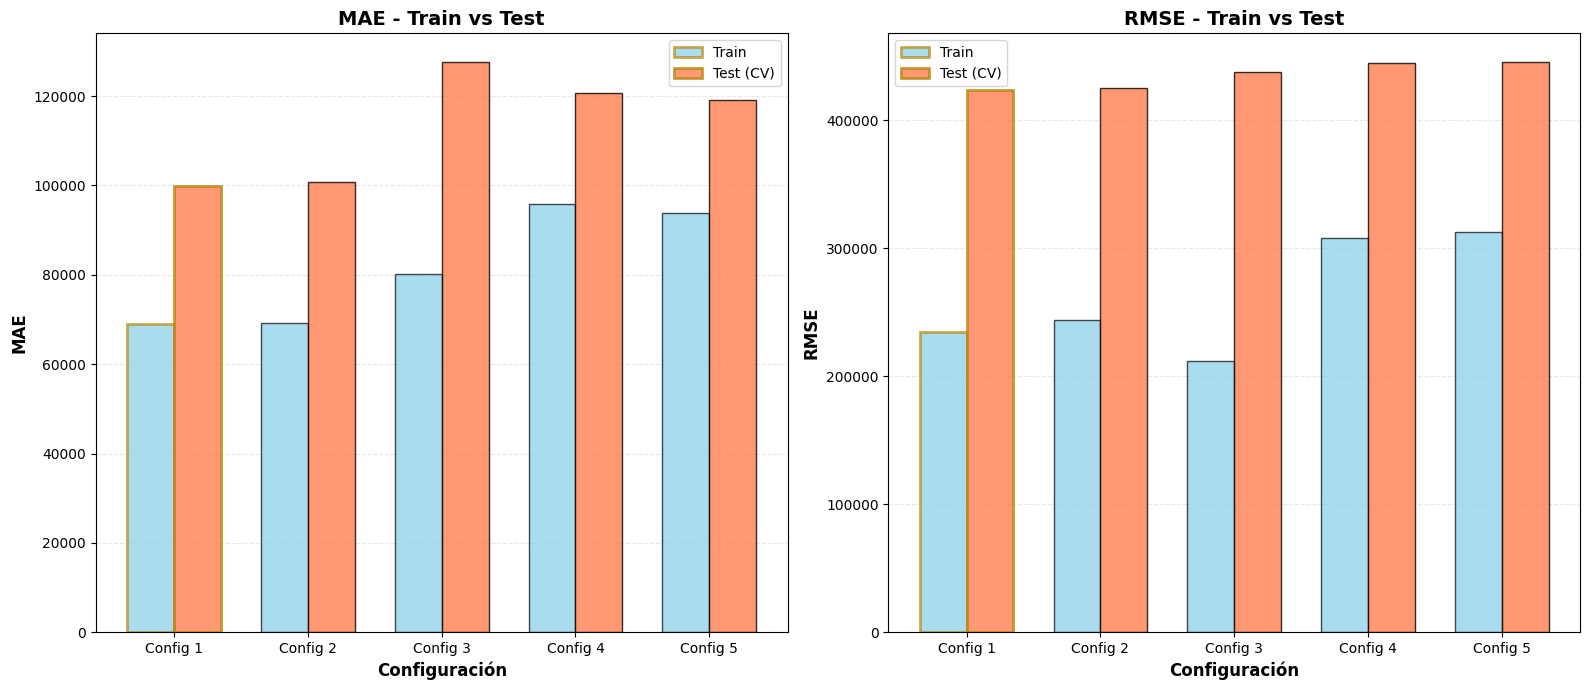


📋 Parámetros de cada configuración:
          colsample_bytree     gamma  learning_rate  max_depth  min_child_weight  n_estimators  reg_lambda  subsample       mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.612572  0.318205       0.104307          9                 5           900    2.699205   0.681224   99871.440149    68969.971887      44.804235
Config 2          0.939566  0.360865       0.080795         12                 9           500    0.127096   0.643157  100775.293035    69122.108306      45.793141
Config 3          0.749816  0.475357       0.229598         10                 7           500    0.779973   0.623233  127667.470047    80140.226910      59.305102
Config 4          0.716858  0.183181       0.146821          8                12           800    2.962073   0.618580  120806.083224    95872.751280      26.006693
Config 5          0.865009  0.155856       0.166020          9                18           500    2.248771   0.758060  119067.907157    93823.8

In [45]:
plot_grid_search_results(xgb_full_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

## 3.3 Grid Search - LightGBM

In [29]:
lgbm_full_results = grid_search_cv(
    model_class=LGBMRegressor,
    param_grid=lgbm_param_grid,
    X=X_full,
    y=y_full,
    feature_pipeline=feature_pipeline_normal,
    target_pipeline=target_pipeline_normal,
    n_splits=3,
    verbose=True,
    n_iter=300,
)


🔍 RandomizedSearchCV: 10 combinaciones × 5 folds = 50 fits
   Modelo: LGBMRegressor



Optimizando:   0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2354
[LightGBM] [Info] Number of data points in the train set: 216577, number of used features: 39
[LightGBM] [Info] Start training from score 81763.850995
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.076037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2354
[LightGBM] [Info] Number of data points in the train set: 216577, number of used features: 39
[LightGBM] [Info] Start training from score 82215.469410
[LightGBM] [Warnin

/Users/gonza/Documents/Gonza/UdeSA/05-machine-learning/alquileres/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.172903 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2353
[LightGBM] [Info] Number of data points in the train set: 216578, number of used features: 39
[LightGBM] [Info] Start training from score 81962.771898
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.275010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2354
[LightGBM] [Info] Number of data points in the train set: 216577, number of used features: 39
[LightGBM] [Info] Start training from score 81763.850995
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[L

In [53]:
lgbm_full_results.to_csv("../results/random_search/lgbm_full.csv")
lgbm_full_results_cut = get_best_not_overfitted(lgbm_full_results)
lgbm_full_results_cut.head()

,colsample_bytree,learning_rate,min_child_samples,min_child_weight,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
9,0.965984,0.256511,21,6.617960,1200,44,2.956489,1.373609,0.824497,107558.169986,1539.196785,418688.355642,41133.361758,78518.313012,1061.359010,263223.462943,5246.579984,36.984820
8,0.602209,0.246484,26,14.226839,800,42,3.029800,4.631504,0.860431,111660.133570,1301.730526,435101.935475,42229.298705,92765.207525,1330.138027,328651.810691,5799.599709,20.368548
4,0.648815,0.153601,44,18.186408,1000,49,3.776807,2.125779,0.683177,112954.975257,1012.081519,443622.496233,41413.526195,96334.906607,1258.782239,354741.509228,7773.873629,17.252385
0,0.749816,0.285707,17,11.973170,500,28,0.499875,2.296244,0.733483,101348.290441,1689.290300,446699.620571,40303.234007,86694.201091,946.238252,354622.011439,7657.120396,16.903194
1,0.657147,0.198758,11,14.439975,500,30,3.087408,3.058266,0.602827,94160.817523,1174.008425,449456.623433,42716.693535,82012.698414,1372.199446,368148.634852,8430.835740,14.812486


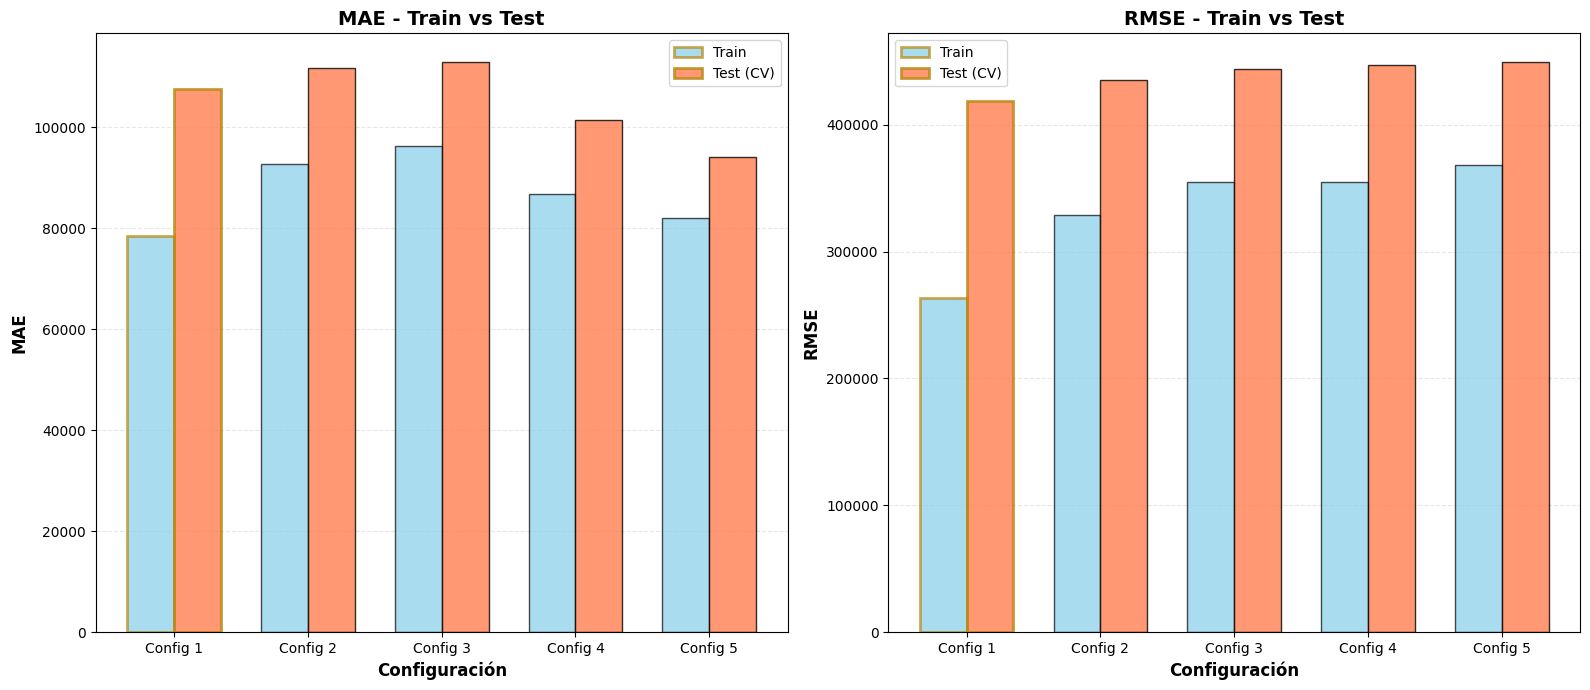


📋 Parámetros de cada configuración:
          colsample_bytree  learning_rate  min_child_samples  min_child_weight  n_estimators  num_leaves  reg_alpha  reg_lambda  subsample       mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.965984       0.256511                 21          6.617960          1200          44   2.956489    1.373609   0.824497  107558.169986    78518.313012      36.984820
Config 2          0.602209       0.246484                 26         14.226839           800          42   3.029800    4.631504   0.860431  111660.133570    92765.207525      20.368548
Config 3          0.648815       0.153601                 44         18.186408          1000          49   3.776807    2.125779   0.683177  112954.975257    96334.906607      17.252385
Config 4          0.749816       0.285707                 17         11.973170           500          28   0.499875    2.296244   0.733483  101348.290441    86694.201091      16.903194
Config 5          0.657147       0.198

In [47]:
plot_grid_search_results(lgbm_full_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

# 4. Conclusiones

Muchos de los modelos, si bien tuvieron mejor performance en test, tuvieron un overfitting severo. En algunos casos, llegaron a tener errores en train cercanos a 0.

Por eso, decidimos hacer un "overfitting cutoff": descartamos aquellos modelos cuyo ratio entre el MAE de test y de train es mayor al 70%. Este es un punto medio para aprovechar la performance de los mejores modelos pero a la vez que puedan generalizar bien.

Entonces, por cada uno de los datasets, nos vamos a quedar con el mejor modelo

## 4.1 Mejor modelo para el dataset normal
LightGBM con la siguiente configuración:
- `colsample_bytree`: 0.96
- learning_rate: 0.25
- min_child_samples: 21
- min_child_weight: 6.6
- n_estimators: 1200
- num_leaves: 44
- reg_alpha: 2.95
- reg_lambda: 1.37
- subsample: 0.82

## 4.2 Mejor modelo para el dataset outliers
LightGBM con la siguiente configuracion
- `colsample_bytree`: 0.61
- learning_rate: 0.031
- min_child_samples: 14
- min_child_weight: 0.03
- min_data_in_leaf: 16
- n_estimators: 1000
- num_leaves: 16
- path_smooth: 1.27
- reg_alpha: 2.57
- reg_lambda: 1.18
- subsample: 0.0.74
- subsample_freq: 1
## 4.3 Mejor modelo para el dataset completo
XGBoost con configuración:
- colsample_bytree: 0.61
- gamma: 0.31
- learning_rate: 0.10
- max_depth: 9
- min_child_weight: 5
- estimators: 900
- reg_lambda: 2.69
- subsample: 0.68